# Face2Comic - Model Training

This notebook trains a pix2pix model that turns real face photos into comic-style images.

## Quick flow
1. Load preprocessed data
2. Build the generator and discriminator
3. Tune key hyperparameters
4. Train the final model
5. Review training results and generated samples

In [1]:
import sys
sys.path.insert(0, "..")

import csv
import time
from pathlib import Path

import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image
from torchinfo import summary

from src.config import SEED, NUM_WORKERS, set_seed, get_device
from src.data import load_data, make_datasets, make_loaders
from src.models import Generator, Discriminator
from src.training import make_models, train_one_epoch, validate
from src.visualization import denorm, save_grid_samples, plot_training_curves
from src.checkpoints import save_checkpoint, load_checkpoint

set_seed(SEED)
print(f"Random seed: {SEED}")
print(f"Number of workers: {NUM_WORKERS}")

from src import training as _training
_training.REAL_LABEL = 0.9

Random seed: 42
Number of workers: 0


## Device Setup

Use CUDA if available, otherwise fall back to MPS (Apple Silicon) or CPU.

In [2]:
DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: cuda


## Load Data

The preprocessing notebook already resized all images to 256x256, converted them to CHW format, and normalized pixel values to [-1, 1]. We load them as memory-mapped arrays so only the batches we need are read into RAM.

In [3]:
data = load_data("../data/npy")

print(f"Train — real: {data['train_real'].shape}, comic: {data['train_comic'].shape}")
print(f"Val   — real: {data['val_real'].shape},   comic: {data['val_comic'].shape}")
print(f"Test  — real: {data['test_real'].shape},  comic: {data['test_comic'].shape}")
print(f"Pixel range: [{data['train_real'][0].min():.1f}, {data['train_real'][0].max():.1f}]")

Train — real: (8000, 3, 256, 256), comic: (8000, 3, 256, 256)
Val   — real: (1000, 3, 256, 256),   comic: (1000, 3, 256, 256)
Test  — real: (1000, 3, 256, 256),  comic: (1000, 3, 256, 256)
Pixel range: [-1.0, 1.0]


## Create Dataset and DataLoader

A thin wrapper that converts memory-mapped NumPy rows into PyTorch tensors on the fly. For the grid search we use a **2 000-sample training subset** and a **500-sample validation subset** to keep each trial fast (~2 min). The full training and validation splits are used for final model training, and the held-out test split is reserved for final evaluation only.

In [4]:
datasets = make_datasets(data, use_train_augmentation=True)

train_dataset = datasets["train"]
full_val_dataset = datasets["val"]
full_test_dataset = datasets["test"]
train_tuning_dataset = datasets["train_tuning"]
val_tuning_dataset = datasets["val_tuning"]

print(f"Train samples (full): {len(train_dataset)}")
print(f"Train samples (tuning subset): {len(train_tuning_dataset)}")
print(f"Val samples (full): {len(full_val_dataset)}")
print(f"Val samples (tuning subset): {len(val_tuning_dataset)}")
print(f"Test samples (full): {len(full_test_dataset)}")

Train samples (full): 8000
Train samples (tuning subset): 2000
Val samples (full): 1000
Val samples (tuning subset): 500
Test samples (full): 1000


/home/gwr4170/.conda/envs/pix2pix/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/projects/e32706/gwr4170/notebooks/../src/data.py:101: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
/projects/e32706/gwr4170/notebooks/../src/data.py:113: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.3),


## Build Generator (U-Net)

The generator is an encoder-decoder with skip connections. The encoder compresses the 256x256 input down to a 4x4 bottleneck, and the decoder upsamples it back. Skip connections carry high-frequency spatial detail (edges, facial features) from encoder to decoder so they survive the bottleneck.

- **Encoder blocks**: Conv2d(stride=2) → InstanceNorm → LeakyReLU
- **Decoder blocks**: ConvTranspose2d(stride=2) → InstanceNorm → ReLU (+ Dropout in first two)
- **Output**: Tanh activation → pixel values in [-1, 1]

In [5]:
generator = Generator()
summary(generator, input_size=(1, 3, 256, 256))

Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [1, 3, 256, 256]          --
├─UNetDown: 1-1                          [1, 64, 128, 128]         --
│    └─Sequential: 2-1                   [1, 64, 128, 128]         --
│    │    └─Conv2d: 3-1                  [1, 64, 128, 128]         3,072
│    │    └─LeakyReLU: 3-2               [1, 64, 128, 128]         --
├─UNetDown: 1-2                          [1, 128, 64, 64]          --
│    └─Sequential: 2-2                   [1, 128, 64, 64]          --
│    │    └─Conv2d: 3-3                  [1, 128, 64, 64]          131,072
│    │    └─InstanceNorm2d: 3-4          [1, 128, 64, 64]          --
│    │    └─LeakyReLU: 3-5               [1, 128, 64, 64]          --
├─UNetDown: 1-3                          [1, 256, 32, 32]          --
│    └─Sequential: 2-3                   [1, 256, 32, 32]          --
│    │    └─Conv2d: 3-6                  [1, 256, 32, 32]          524,288
│ 

## Build Discriminator (PatchGAN)

In [6]:
discriminator = Discriminator()
summary(discriminator, input_size=[(1, 3, 256, 256), (1, 3, 256, 256)])

Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [1, 1, 30, 30]            --
├─Sequential: 1-1                        [1, 1, 30, 30]            --
│    └─Conv2d: 2-1                       [1, 64, 128, 128]         6,144
│    └─LeakyReLU: 2-2                    [1, 64, 128, 128]         --
│    └─Conv2d: 2-3                       [1, 128, 64, 64]          131,072
│    └─BatchNorm2d: 2-4                  [1, 128, 64, 64]          256
│    └─LeakyReLU: 2-5                    [1, 128, 64, 64]          --
│    └─Conv2d: 2-6                       [1, 256, 32, 32]          524,288
│    └─BatchNorm2d: 2-7                  [1, 256, 32, 32]          512
│    └─LeakyReLU: 2-8                    [1, 256, 32, 32]          --
│    └─Conv2d: 2-9                       [1, 512, 31, 31]          2,097,152
│    └─BatchNorm2d: 2-10                 [1, 512, 31, 31]          1,024
│    └─LeakyReLU: 2-11                   [1, 512, 31, 31]   

### Initialize Weights

Standard pix2pix initialization: draw conv weights from N(0, 0.02) and set BatchNorm weights to N(1, 0.02) with zero bias.

In [7]:
_g = Generator()
_d = Discriminator()
print(f"Generator params:     {sum(p.numel() for p in _g.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in _d.parameters()):,}")
del _g, _d

Generator params:     29,238,275
Discriminator params: 2,768,641


## Define Loss Functions

Two losses work together to make generated comics as close as possible to the ground truth:

| Loss | Purpose |
|------|--------|
| **BCE (adversarial)** | Fools the discriminator — makes outputs look "real" |
| **L1 (pixel)** | Penalizes pixel-level deviation from the target comic |

The generator loss is: `G_loss = BCE + λ_L1 × L1`

## Run Hyperparameter Search

We search over **3 learning rates × 3 batch sizes × 3 L1 weights = 27 configurations**. Each one trains for 10 short epochs on a **2 000-sample training subset** and is validated on the 500-sample tuning subset — this keeps each trial fast (~2 min).

The CSV log is written after every config so nothing is lost if the kernel dies. The best config (lowest validation L1) gets its checkpoint saved.

In [8]:
GRID_SAMPLE_DIR = Path("output/grid_search_samples+4_model_training")
GRID_SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

GRID_RESULTS_DIR = Path("output/grid_search_results+4_model_training")
GRID_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = Path("../output/checkpoints+4_model_training")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

## Train Final Model

Now we train for **200 epochs** using the winning hyperparameters from the grid search. Key additions:

- **LR scheduling**: linear decay from the original LR to 0 over the second half of training (epochs 101–200) for stable convergence
- **Checkpoints**: saved every 10 epochs + the single best model (by validation L1)
- **CSV logging**: every epoch is appended immediately

In [9]:
BEST_LR = 5e-4
BEST_BS = 32
BEST_LAMBDA_L1 = 100
NUM_EPOCHS = 300
CHECKPOINT_EVERY = 5
DECAY_START = 150

print("Full training configuration:")
print(f"  LR:       {BEST_LR:.0e}")
print(f"  Batch:    {BEST_BS}")
print(f"  λ_L1:     {BEST_LAMBDA_L1}")
print(f"  Epochs:   {NUM_EPOCHS}")
print(f"  LR decay: linear from epoch {DECAY_START}")

gen, disc, opt_gen, opt_disc = make_models(BEST_LR, device=DEVICE)
train_loader, val_loader = make_loaders(BEST_BS, train_dataset, full_val_dataset, DEVICE)

LAMBDA_START = 150
LAMBDA_END = 75

def lr_lambda(epoch):
    if epoch < DECAY_START:
        return 1.0
    return 1.0 - ((epoch - DECAY_START) / (NUM_EPOCHS - DECAY_START))*0.8

sched_gen = optim.lr_scheduler.LambdaLR(opt_gen, lr_lambda)
sched_disc = optim.lr_scheduler.LambdaLR(opt_disc, lr_lambda)

Full training configuration:
  LR:       5e-04
  Batch:    32
  λ_L1:     100
  Epochs:   300
  LR decay: linear from epoch 150


### Run Training Loop

In [10]:
TRAIN_LOG_DIR = Path("output/training_logs+4_model_training")
TRAIN_LOG_DIR.mkdir(parents=True, exist_ok=True)

EPOCH_SAMPLE_DIR = Path("output/epoch_samples+4_model_training")
EPOCH_SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CURVES_DIR = Path("output/training_curves+4_model_training")
TRAIN_CURVES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = TRAIN_LOG_DIR / "full_training_log.csv"

with open(TRAIN_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["epoch", "g_loss", "d_loss", "val_l1", "lr", "time_sec"])
    writer.writeheader()

history = {"epoch": [], "g_loss": [], "d_loss": [], "val_l1": [], "lr": []}
best_val = float("inf")
best_epoch = 0

snapshot_epochs = [i for i in range(NUM_EPOCHS) if i%5 == 0]
                                                                    

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    g_loss, d_loss = train_one_epoch(gen, disc, train_loader, opt_gen, opt_disc, BEST_LAMBDA_L1, DEVICE)
    val_l1 = validate(gen, val_loader, DEVICE)

    sched_gen.step()
    sched_disc.step()
    current_lr = opt_gen.param_groups[0]["lr"]
    elapsed = time.time() - t0

    history["epoch"].append(epoch)
    history["g_loss"].append(g_loss)
    history["d_loss"].append(d_loss)
    history["val_l1"].append(val_l1)
    history["lr"].append(current_lr)

    row = {"epoch": epoch, "g_loss": round(g_loss, 6), "d_loss": round(d_loss, 6),
           "val_l1": round(val_l1, 6), "lr": round(current_lr, 8), "time_sec": round(elapsed, 2)}
    with open(TRAIN_CSV, "a", newline="") as f:
        csv.DictWriter(f, fieldnames=row.keys()).writerow(row)

    print(f"Epoch {epoch:3d}/{NUM_EPOCHS}  G={g_loss:.4f}  D={d_loss:.4f}  "
          f"Val_L1={val_l1:.4f}  LR={current_lr:.6f}  ({elapsed:.1f}s)")

    # save periodic checkpoint
    if epoch % CHECKPOINT_EVERY == 0:
        p = save_checkpoint(gen, disc, opt_gen, opt_disc, epoch,
                            {"g_loss": g_loss, "d_loss": d_loss, "val_l1": val_l1},
                            CHECKPOINT_DIR)
        print(f"  ✓ Checkpoint saved: {p.name}")

    # save best model
    if val_l1 < best_val:
        best_val = val_l1
        best_epoch = epoch
        save_checkpoint(gen, disc, opt_gen, opt_disc, epoch,
                        {"g_loss": g_loss, "d_loss": d_loss, "val_l1": val_l1},
                        CHECKPOINT_DIR, name="pix2pix_best")
        print(f"  ★ New best model (Val L1={val_l1:.4f})")

    # save sample snapshots at milestone epochs
    if epoch in snapshot_epochs:
        gen.eval()
        with torch.no_grad():
            fig, axes = plt.subplots(4, 3, figsize=(9, 12))
            axes[0, 0].set_title("Real")
            axes[0, 1].set_title("Generated")
            axes[0, 2].set_title("Target")
            for i in range(4):
                real, target = full_val_dataset[i]
                fake = gen(real.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()
                axes[i, 0].imshow(denorm(real).permute(1, 2, 0).numpy())
                axes[i, 1].imshow(denorm(fake).permute(1, 2, 0).numpy())
                axes[i, 2].imshow(denorm(target).permute(1, 2, 0).numpy())
                for j in range(3):
                    axes[i, j].axis("off")
            fig.suptitle(f"Epoch {epoch}", fontsize=14, fontweight="bold")
            plt.tight_layout()
            fig.savefig(EPOCH_SAMPLE_DIR / f"epoch_{epoch:03d}.png", dpi=100)
            plt.close(fig)

print(f"\nTraining complete! Best Val L1 = {best_val:.4f} at epoch {best_epoch}")

100%|██████████| 250/250 [02:43<00:00,  1.53it/s, D=0.485, G=25.674]


Epoch   1/300  G=26.9004  D=0.5710  Val_L1=0.2242  LR=0.000500  (164.8s)
  ★ New best model (Val L1=0.2242)


100%|██████████| 250/250 [00:42<00:00,  5.83it/s, D=0.427, G=24.346]


Epoch   2/300  G=25.8073  D=0.5274  Val_L1=0.2359  LR=0.000500  (43.6s)


100%|██████████| 250/250 [00:42<00:00,  5.85it/s, D=0.477, G=26.371]


...

Epoch 298/300  G=23.7463  D=0.1727  Val_L1=0.2122  LR=0.000105  (43.4s)


100%|██████████| 250/250 [00:42<00:00,  5.84it/s, D=0.176, G=24.065]


Epoch 299/300  G=23.7543  D=0.1727  Val_L1=0.2083  LR=0.000103  (43.5s)


100%|██████████| 250/250 [00:42<00:00,  5.82it/s, D=0.169, G=21.353]


Epoch 300/300  G=23.7361  D=0.1760  Val_L1=0.2061  LR=0.000100  (43.6s)
  ✓ Checkpoint saved: pix2pix_epoch_300.pt

Training complete! Best Val L1 = 0.1991 at epoch 263


## Figures
**Inference** snippets follow **`plot_training_curves`** (3-panel PNG) and the **epoch montage** below.


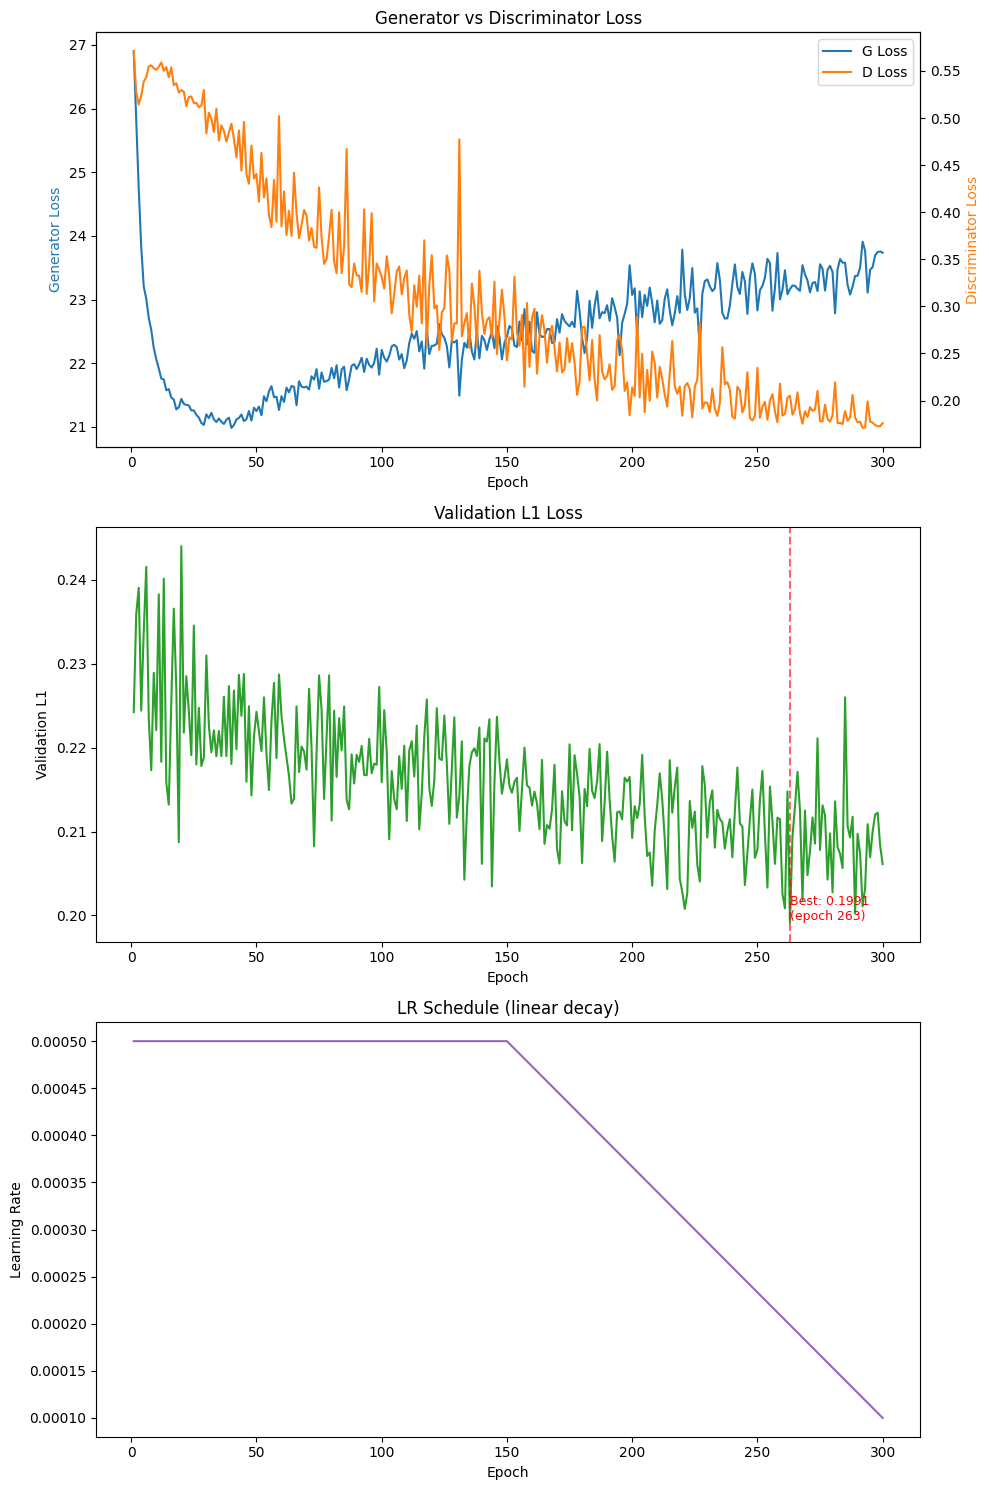

In [11]:
plot_training_curves(history, best_epoch, best_val, TRAIN_CURVES_DIR)

**Training curves:** **Val L1** should mostly **fall**; the red dash marks the **best-saved epoch**. **LR** should hold steady then **step/slope down** when decay activates. **G vs D:** both **oscillating in a moderate band** is normal; watch for runaway spikes or one curve pinned near zero (**mode collapse risk**).


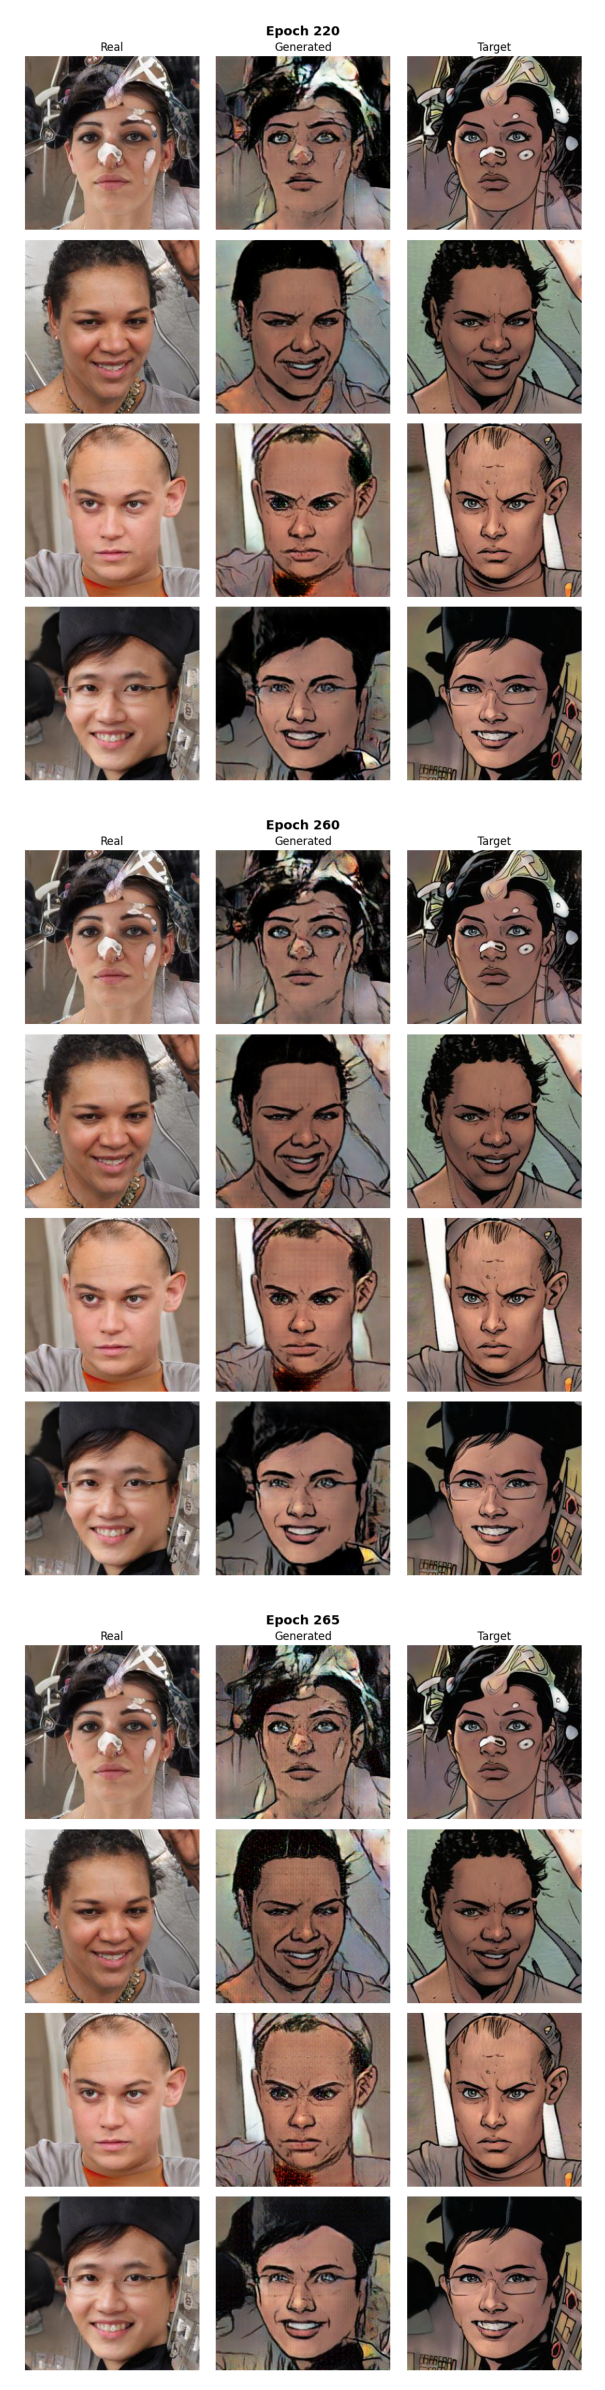

In [13]:
epochs_to_show = [220, 260, 265]

snapshot_files = [
    EPOCH_SAMPLE_DIR / f"epoch_{e:03d}.png"
    for e in epochs_to_show
]

if snapshot_files:
    fig, axes = plt.subplots(len(snapshot_files), 1, figsize=(8, 8 * len(snapshot_files)))

    if len(snapshot_files) == 1:
        axes = [axes]

    for ax, path in zip(axes, snapshot_files):
        img = Image.open(path)
        ax.imshow(img)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No snapshot images found.")

**Epoch snapshots:** Compare **Generated** to **Target** — later epochs should tighten **edges/inks** without swapping **identity**. If **L1** improves but outputs **muddy or same-y**, prioritize what you see over the scalar.


## Key Takeaways

- The model was trained end-to-end using the prepared dataset and pix2pix pipeline.
- Hyperparameter tuning helped choose stable settings for final training.
- Training plots and sample outputs were used to check learning quality over time.
- Final model checkpoints were saved for evaluation and inference in the next notebook.